<a href="https://colab.research.google.com/github/kananshr13/CSET-343-Ai-in-Healthcare/blob/main/Lab_Experiment_2_CSET343.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [3]:
import kagglehub

path = kagglehub.dataset_download("andrewmvd/heart-failure-clinical-data")

print("Path to dataset files:", path)

100%|██████████| 3.97k/3.97k [00:00<00:00, 3.55MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/andrewmvd/heart-failure-clinical-data/versions/1


In [6]:
import os

csv_file_path = os.path.join(path, "heart_failure_clinical_records_dataset.csv")
df = pd.read_csv(csv_file_path)
print("First 5 rows of Heartfailure dataset:")
print(df.head())

First 5 rows of Heartfailure dataset:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1 

In [7]:
print("No. of rows: ")
print(df.shape[0])
print("No. of cols: ")
print(df.shape[1])
print("No. of Datatypes: ")
print(df.dtypes.value_counts())
print("No. of Missing Values: ")
print(df.isnull().sum())

No. of rows: 
299
No. of cols: 
13
No. of Datatypes: 
int64      10
float64     3
Name: count, dtype: int64
No. of Missing Values: 
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


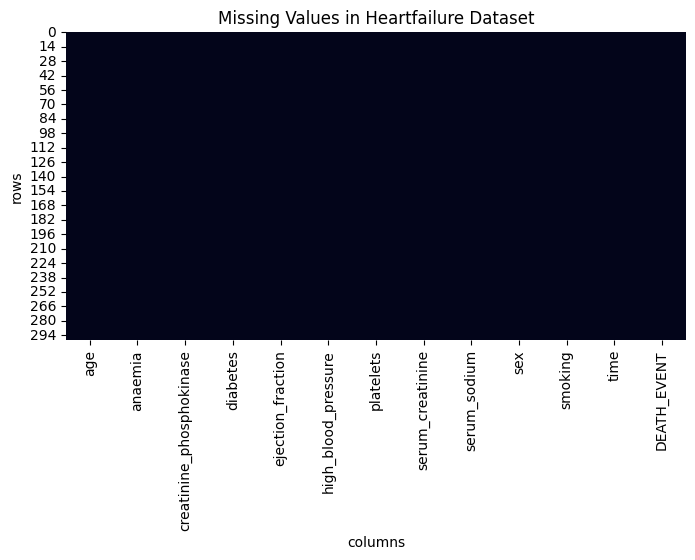

In [11]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values in Heartfailure Dataset")
plt.xlabel("columns")
plt.ylabel("rows")
plt.show()


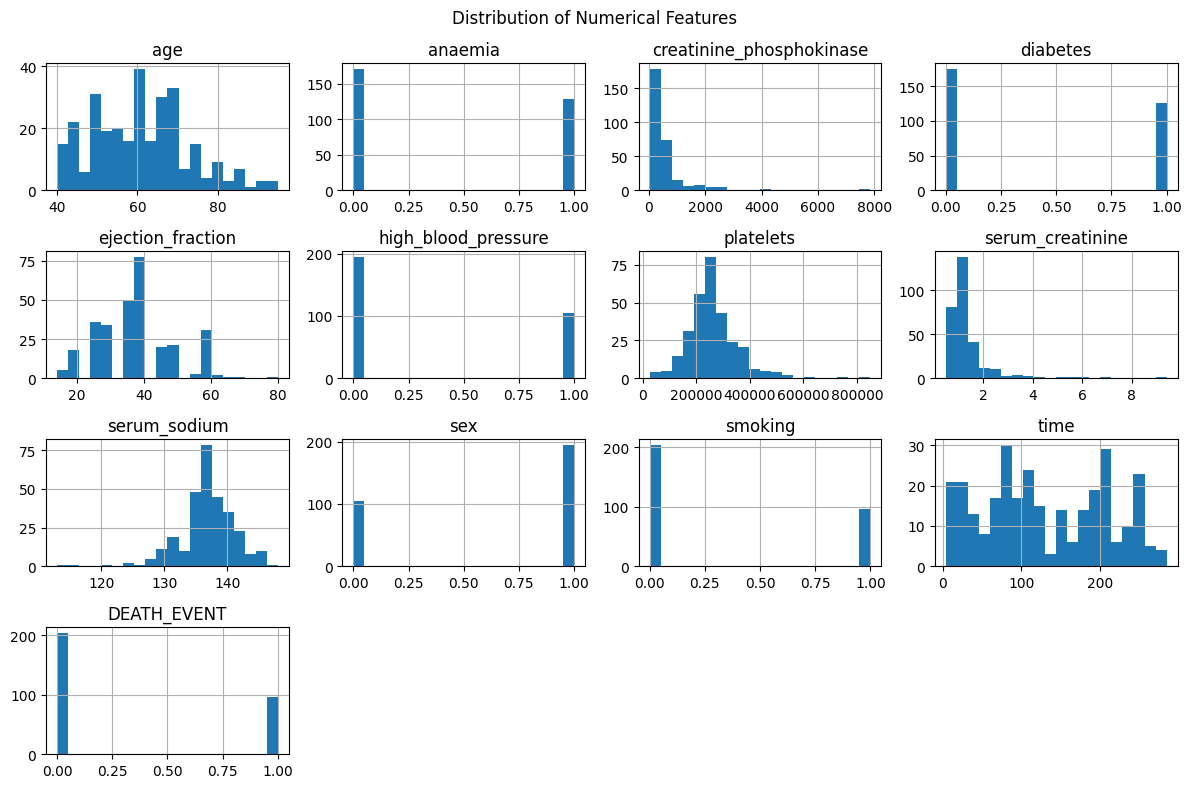

In [12]:
df.hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()

plt.show()

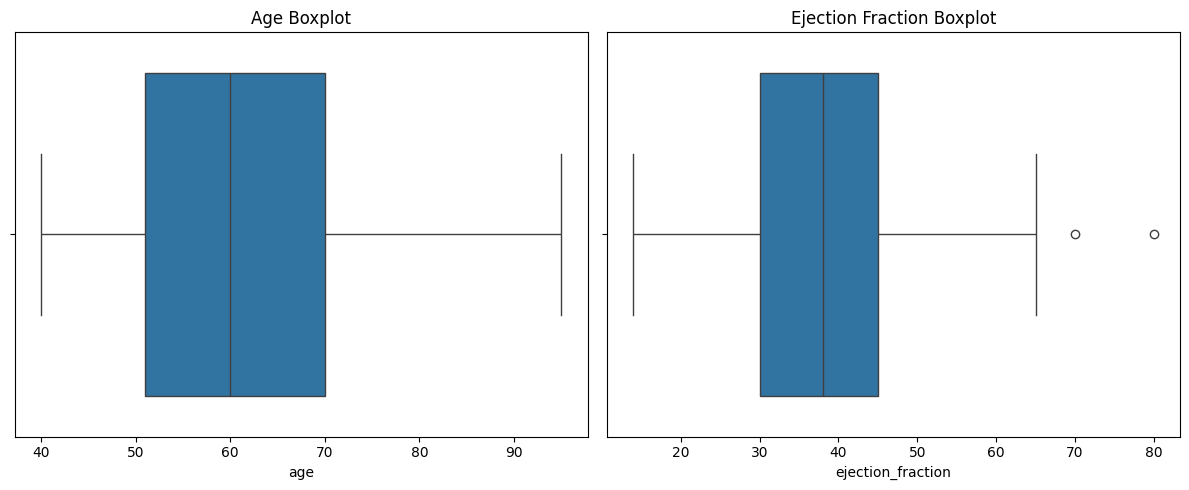

In [13]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["age"])
plt.title("Age Boxplot")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["ejection_fraction"])
plt.title("Ejection Fraction Boxplot")

plt.tight_layout()
plt.show()

In [14]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())


In [15]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])


print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [16]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[
        (df[column] >= lower_limit) &
        (df[column] <= upper_limit)
    ]

print("\nShape after removing outliers:")
print(df.shape)


Shape after removing outliers:
(224, 13)


In [17]:
df.loc[df["age"] < 0, "age"] = df["age"].median()

df.loc[
    df["ejection_fraction"] < 0,
    "ejection_fraction"
] = df["ejection_fraction"].median()

df.loc[
    df["serum_creatinine"] <= 0,
    "serum_creatinine"
] = df["serum_creatinine"].median()

print("\nInvalid values corrected.")




Invalid values corrected.


In [18]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"]
)

In [20]:
df["risk_score"] = (
    df["serum_creatinine"] /
    df["ejection_fraction"]
)
print("\nNew features:")
print(df[["age", "age_group", "ejection_fraction",
          "serum_creatinine", "risk_score"]].head())



New features:
    age age_group  ejection_fraction  serum_creatinine  risk_score
0  75.0       >60                 20               1.9      0.0950
2  65.0       >60                 20               1.3      0.0650
3  50.0     40-60                 20               1.9      0.0950
5  90.0       >60                 40               2.1      0.0525
6  75.0       >60                 15               1.2      0.0800


In [26]:
if "age_group" in df.columns:
    df = pd.get_dummies(
        df,
        columns=["age_group"],
        drop_first=True
    )
    print("\n'age_group' column one-hot encoded.")
else:
    print("\n'age_group' column not found in DataFrame. It might have already been one-hot encoded.")


'age_group' column not found in DataFrame. It might have already been one-hot encoded.


In [27]:
df = df.astype({
    column: "int"
    for column in df.select_dtypes(include=["bool"]).columns
})

print("\nDataset after encoding:")
print(df.head())



Dataset after encoding:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
5  90.0        1                        47         0                 40   
6  75.0        1                       246         0                 15   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1   265000.0               1.9           130    1   
2                    0   162000.0               1.3           129    1   
3                    0   210000.0               1.9           137    1   
5                    1   204000.0               2.1           132    1   
6                    0   127000.0               1.2           137    1   

   smoking  time  DEATH_EVENT  risk_score  age_group_40-60  age_group_>60  
0  

In [28]:
scaler = MinMaxScaler()

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

# Do not normalize the target variable DEATH_EVENT

columns_to_scale = [
    column for column in numerical_columns
    if column != "DEATH_EVENT"
]

df[columns_to_scale] = scaler.fit_transform(
    df[columns_to_scale]
)

print("\nDataset after normalization:")
print(df.head())



Dataset after normalization:
        age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  0.636364      0.0                  0.470990       0.0           0.117647   
2  0.454545      0.0                  0.098976       0.0           0.117647   
3  0.181818      1.0                  0.069113       0.0           0.117647   
5  0.909091      1.0                  0.014505       0.0           0.509804   
6  0.636364      1.0                  0.184300       0.0           0.019608   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                  1.0   0.468852          0.866667      0.217391  1.0   
2                  0.0   0.131148          0.466667      0.173913  1.0   
3                  0.0   0.288525          0.866667      0.521739  1.0   
5                  1.0   0.268852          1.000000      0.304348  1.0   
6                  0.0   0.016393          0.400000      0.521739  1.0   

   smoking      time  DEATH_EVENT  risk_score  age

In [29]:
print("\nSummary statistics AFTER cleaning:")

print(
    df.describe().T[
        ["mean", "50%", "std", "min", "max"]
    ]
)



Summary statistics AFTER cleaning:
                              mean       50%       std  min  max
age                       0.378355  0.363636  0.217202  0.0  1.0
anaemia                   0.468750  0.000000  0.500140  0.0  1.0
creatinine_phosphokinase  0.261896  0.155290  0.238499  0.0  1.0
diabetes                  0.419643  0.000000  0.494606  0.0  1.0
ejection_fraction         0.474090  0.470588  0.229624  0.0  1.0
high_blood_pressure       0.379464  0.000000  0.486340  0.0  1.0
platelets                 0.438902  0.460656  0.220176  0.0  1.0
serum_creatinine          0.352381  0.333333  0.218530  0.0  1.0
serum_sodium              0.523680  0.521739  0.165510  0.0  1.0
sex                       0.642857  1.000000  0.480231  0.0  1.0
smoking                   0.321429  0.000000  0.468071  0.0  1.0
time                      0.457836  0.412811  0.272526  0.0  1.0
DEATH_EVENT               0.272321  0.000000  0.446151  0.0  1.0
risk_score                0.260947  0.202857  0.207940

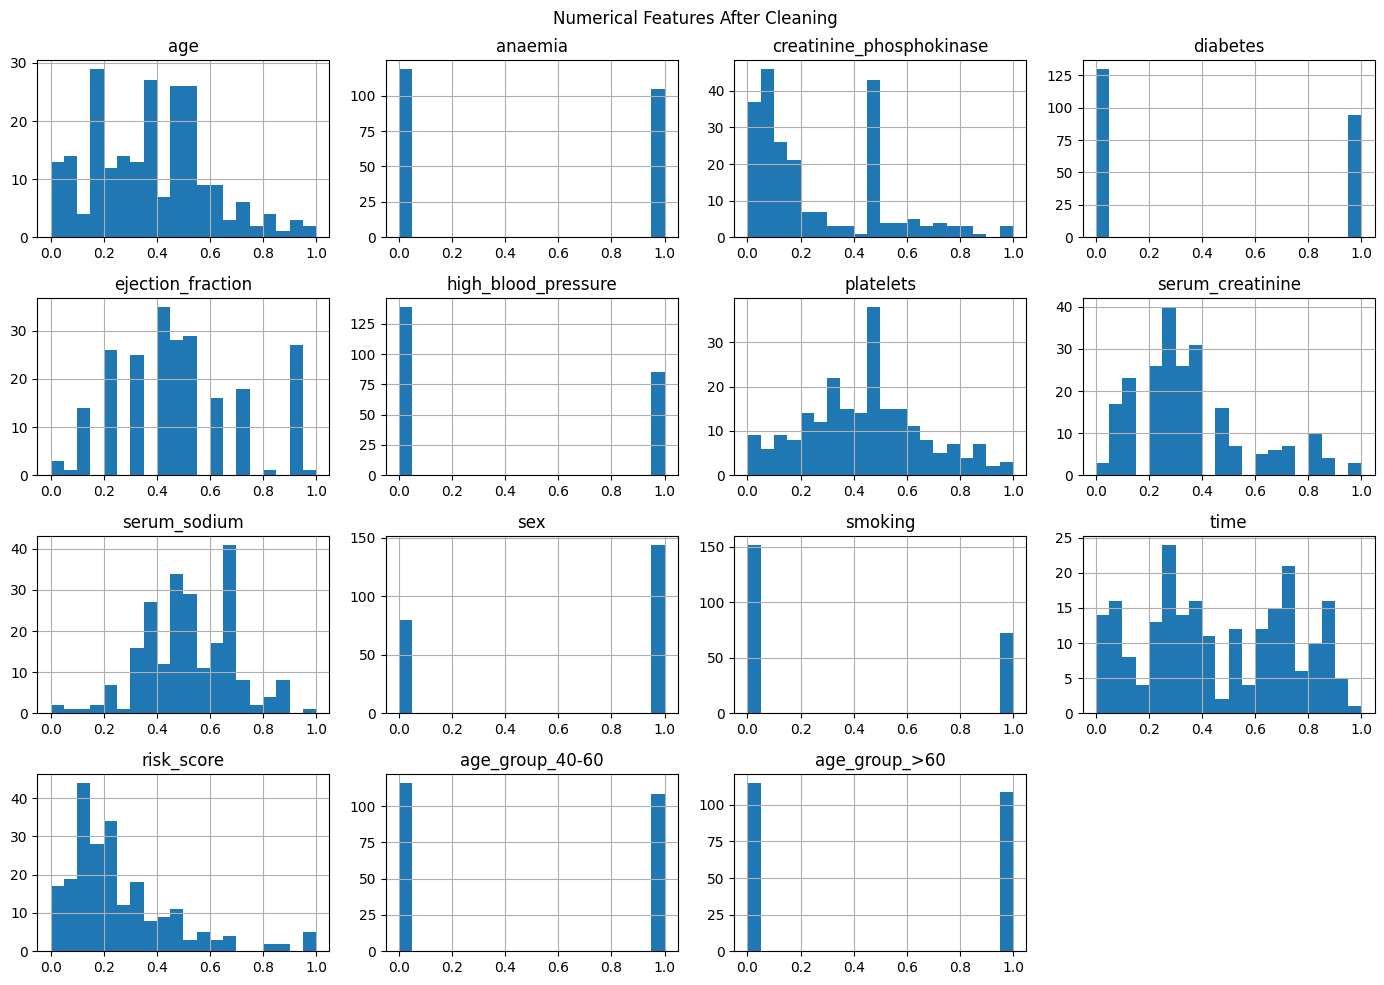

In [30]:

df[columns_to_scale].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle(
    "Numerical Features After Cleaning"
)

plt.tight_layout()
plt.show()



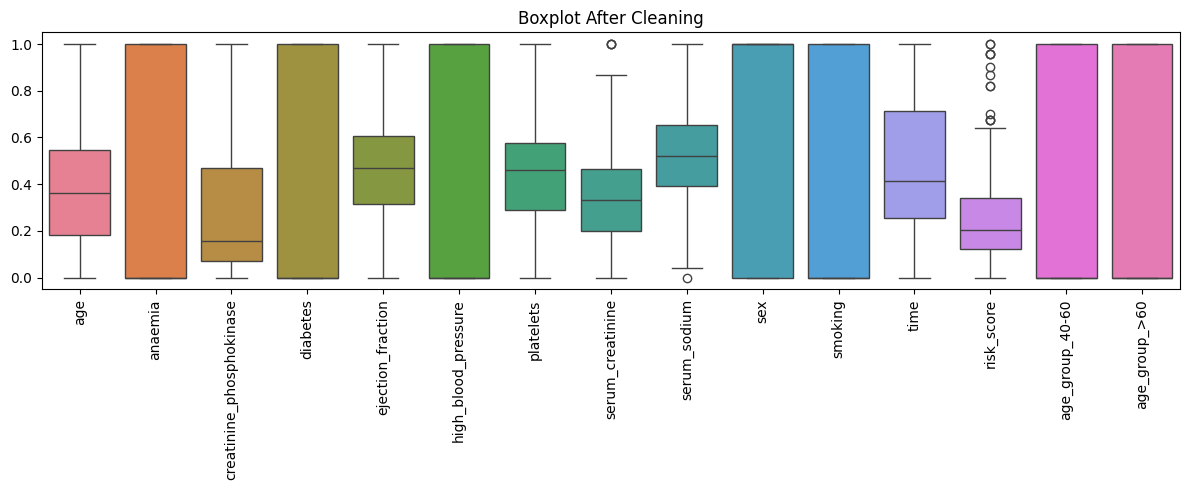

In [31]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df[columns_to_scale]
)

plt.title("Boxplot After Cleaning")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


In [32]:
print("\nFinal missing values:")

print(df.isnull().sum())

print("\nTotal missing values:",
      df.isnull().sum().sum())


if df.isnull().sum().sum() == 0:
    print("No missing values remain.")



Final missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_40-60             0
age_group_>60               0
dtype: int64

Total missing values: 0
No missing values remain.


In [33]:
df.to_csv(
    "cleaned_heart_failure_dataset.csv",
    index=False
)

print("\nCleaned dataset saved successfully.")


Cleaned dataset saved successfully.
